#Heathcare Disease Prediction using Machine Learning

## Project overview

This project develops a basic predictive analytics model using historical healthcare data. The objective is to predict the likelihood of diabetes based on patient demographic and clinical characteristics.

The project includes data preprocessing, exploratory data analysis, model development, prediction, and model evaluation.



## Objective

The main objective of this project is to develop a simple machine-learning model that predicts diabetes outcome using historical patient data.

### Specific Objectives

1. Load and understand the healthcare dataset.
2. Check and preprocess the data.
3. Perform exploratory data analysis.
4. Build a Logistic Regression classification model.
5. Predict diabetes outcomes for test data.
6. Evaluate model performance using accuracy, precision, recall, and F1-score.
7. Visualize the model results using charts and a confusion matrix.
8. Identify important variables contributing to the prediction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 3. Dataset

The dataset contains historical patient information and diabetes outcomes. It includes demographic and clinical variables such as pregnancies, glucose level, blood pressure, BMI, insulin, age, and diabetes outcome.

In [3]:
import pandas as pd

df = pd.read_csv("diabetes_healthcare_dataset.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,116,57,26,93,36.8,0.630,66,1
1,3,146,53,18,159,33.2,0.344,39,1
2,12,159,63,25,196,30.9,0.144,55,1
3,10,80,73,22,157,22.4,0.404,66,1
4,7,146,75,20,191,23.5,0.854,60,1


In [4]:
print("Number of rows and columns:")
print(df.shape)

print("\nDataset information:")
df.info()

Number of rows and columns:
(400, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               400 non-null    int64  
 1   Glucose                   400 non-null    int64  
 2   BloodPressure             400 non-null    int64  
 3   SkinThickness             400 non-null    int64  
 4   Insulin                   400 non-null    int64  
 5   BMI                       400 non-null    float64
 6   DiabetesPedigreeFunction  400 non-null    float64
 7   Age                       400 non-null    int64  
 8   Outcome                   400 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 28.3 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,6.450000,120.280000,73.200000,25.447500,121.542500,32.413750,0.380292,47.117500,0.690000
std,4.073572,31.085243,12.819941,8.489843,59.830698,5.853969,0.271317,15.711008,0.463072
min,0.000000,60.000000,45.000000,5.000000,15.000000,18.000000,0.050000,21.000000,0.000000
25%,3.000000,98.750000,64.000000,19.000000,77.000000,28.300000,0.182750,34.000000,0.000000
50%,6.000000,121.500000,72.000000,25.000000,122.000000,32.700000,0.328500,46.000000,1.000000
75%,10.000000,143.000000,82.000000,31.250000,163.000000,36.400000,0.510750,62.000000,1.000000
max,13.000000,200.000000,110.000000,50.000000,274.000000,48.000000,2.066000,74.000000,1.000000


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
df.duplicated().sum()

np.int64(0)

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of diabetes outcomes and examine patterns in the clinical variables.

In [8]:
df["Outcome"].value_counts()

,count
Outcome,
1,276
0,124


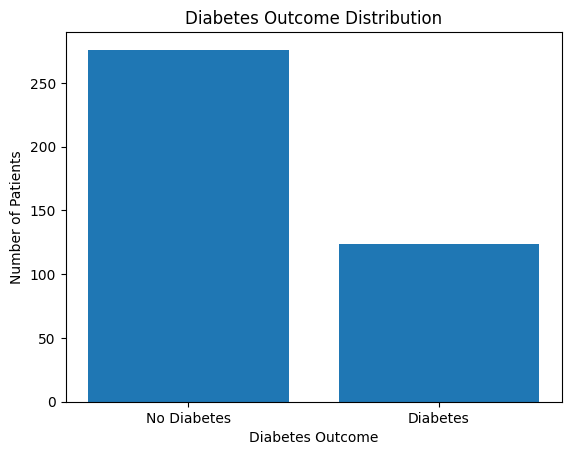

In [9]:
outcome_counts = df["Outcome"].value_counts()

plt.bar(["No Diabetes", "Diabetes"], outcome_counts)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Number of Patients")

plt.show()

### Glucose Level Distribution

Glucose levels were examined to understand their distribution across the patient population.

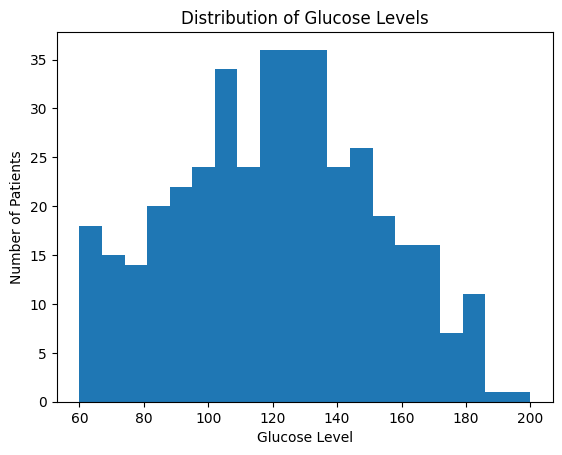

In [10]:
plt.hist(df["Glucose"], bins=20)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose Level")
plt.ylabel("Number of Patients")

plt.show()

### Glucose Levels by Diabetes Outcome

Glucose levels were compared between patients with and without the diabetes outcome to identify differences in the observed distributions.

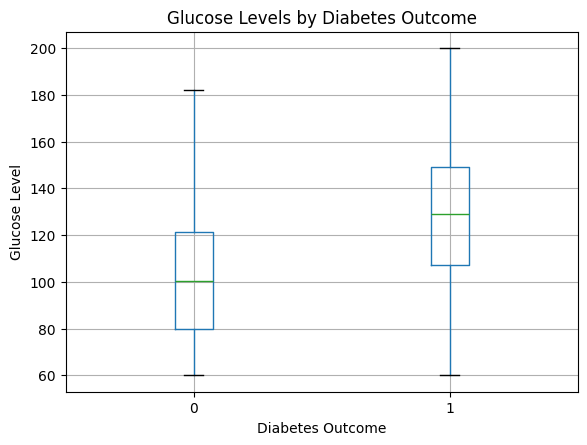

In [11]:
df.boxplot(column="Glucose", by="Outcome")

plt.title("Glucose Levels by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose Level")

plt.show()

## 5. Data Preparation

The dataset was prepared for machine-learning analysis by separating the predictor variables from the target variable.

The clinical and demographic variables are used as predictors, while Outcome is the target variable.

In [12]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Predictor variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Predictor variables:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable:
Outcome


## 6. Train-Test Split

The dataset was divided into training and testing sets. The training set is used to develop the model, while the testing set is used to evaluate its performance on previously unseen data.

An 80:20 split was used.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (320, 8)
Testing data: (80, 8)


## 7. Model Development

Logistic Regression was selected because the target variable is binary, with two possible outcomes: 0 (No Diabetes) and 1 (Diabetes).

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 8. Prediction

The trained Logistic Regression model was used to predict diabetes outcomes for the test dataset.

In [16]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print(y_pred)

Predictions generated successfully.
[1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1
 1 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 0
 0 1 1 1 1 1]


## 9. Model Evaluation

The performance of the Logistic Regression model was evaluated using accuracy, precision, recall, and F1-score.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

Model Performance
------------------
Accuracy : 0.812
Precision: 0.823
Recall   : 0.927
F1 Score : 0.872


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.56      0.65        25
           1       0.82      0.93      0.87        55

    accuracy                           0.81        80
   macro avg       0.80      0.74      0.76        80
weighted avg       0.81      0.81      0.80        80



## 10. Confusion Matrix

A confusion matrix was used to compare the actual diabetes outcomes with the outcomes predicted by the machine-learning model.

In [19]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14 11]
 [ 4 51]]


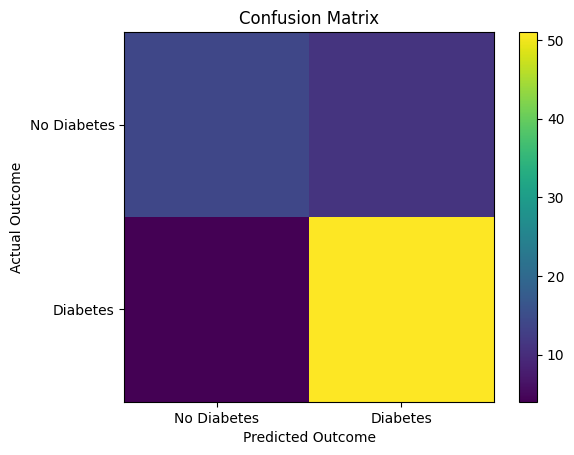

In [20]:
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

plt.colorbar()

plt.show()

## 11. Feature Importance

The Logistic Regression coefficients were examined to understand the relative contribution of the predictor variables to the model.

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.587338
0,Pregnancies,0.161098
1,Glucose,0.034622
5,BMI,0.032197
7,Age,0.021739
4,Insulin,-0.001982
2,BloodPressure,-0.006842
3,SkinThickness,-0.008489


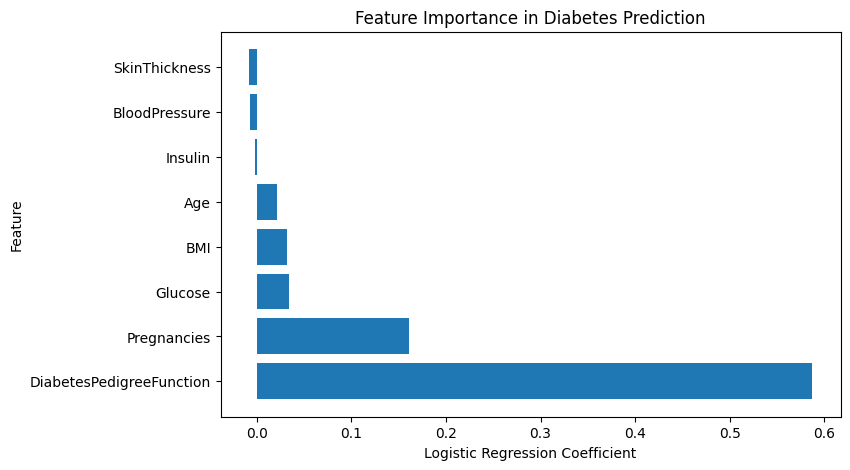

In [22]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.title("Feature Importance in Diabetes Prediction")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

## 11. Standardized Feature Importance

The predictor variables were standardized before fitting a second Logistic Regression model so that the relative magnitude of the model coefficients could be compared more appropriately across variables with different measurement scales.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_model = LogisticRegression(max_iter=1000)

scaled_model.fit(X_train_scaled, y_train)

y_pred_scaled = scaled_model.predict(X_test_scaled)

In [26]:
standardized_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": scaled_model.coef_[0]
})

standardized_importance["Absolute_Coefficient"] = (
    standardized_importance["Coefficient"].abs()
)

standardized_importance = standardized_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

standardized_importance

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.032944,1.032944
0,Pregnancies,0.636185,0.636185
7,Age,0.323053,0.323053
6,DiabetesPedigreeFunction,0.194443,0.194443
5,BMI,0.183032,0.183032
4,Insulin,-0.117114,0.117114
2,BloodPressure,-0.090923,0.090923
3,SkinThickness,-0.072937,0.072937


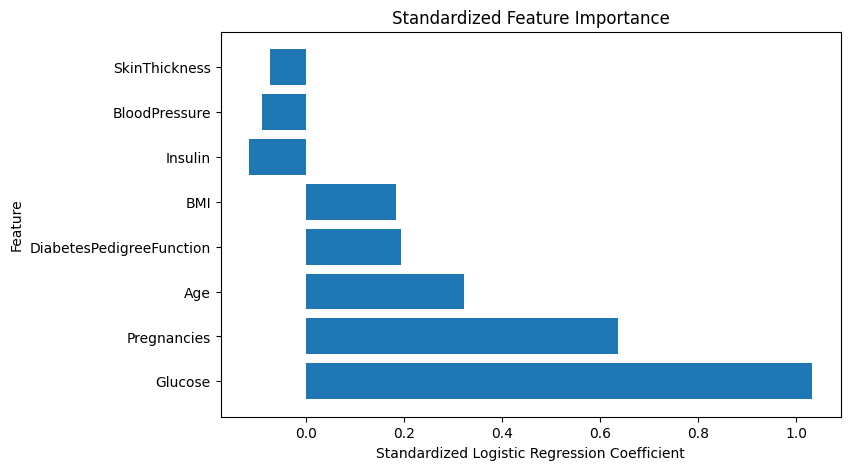

In [27]:
plt.figure(figsize=(8, 5))

plt.barh(
    standardized_importance["Feature"],
    standardized_importance["Coefficient"]
)

plt.title("Standardized Feature Importance")
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

## 12. Evaluation of Standardized Model

The standardized Logistic Regression model was evaluated using the same performance metrics to assess its predictive performance.

In [29]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled)
recall_scaled = recall_score(y_test, y_pred_scaled)
f1_scaled = f1_score(y_test, y_pred_scaled)

print("Standardized Model Performance")
print("------------------------------")
print("Accuracy :", round(accuracy_scaled, 3))
print("Precision:", round(precision_scaled, 3))
print("Recall   :", round(recall_scaled, 3))
print("F1 Score :", round(f1_scaled, 3))

Standardized Model Performance
------------------------------
Accuracy : 0.812
Precision: 0.823
Recall   : 0.927
F1 Score : 0.872


## 13. Sample Patient Prediction

A sample patient record was provided to the trained standardized Logistic Regression model to demonstrate how the model generates a predicted diabetes outcome.

In [30]:
# Sample patient data
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [120],
    "BloodPressure": [70],
    "SkinThickness": [25],
    "Insulin": [80],
    "BMI": [30.5],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [35]
})

# Standardize the sample patient using the fitted scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict outcome
prediction = scaled_model.predict(new_patient_scaled)

# Predict probability
probability = scaled_model.predict_proba(new_patient_scaled)[0][1]

print("Predicted Outcome:", prediction[0])
print("Predicted Probability of Outcome 1:", round(probability, 3))

if prediction[0] == 1:
    print("Model classification: Diabetes outcome predicted")
else:
    print("Model classification: No diabetes outcome predicted")

Predicted Outcome: 1
Predicted Probability of Outcome 1: 0.566
Model classification: Diabetes outcome predicted


## 14. Final Model Results

The Logistic Regression model was evaluated on 20% of the dataset that was held out for testing.

The model achieved an accuracy of 81.2%, precision of 82.3%, recall of 92.7%, and F1-score of 87.2%.

The high recall indicates that the model identified a large proportion of patients belonging to the diabetes outcome group in the test dataset.

In [31]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_scaled,
        precision_scaled,
        recall_scaled,
        f1_scaled
    ]
})

results

,Metric,Score
0,Accuracy,0.812500
1,Precision,0.822581
2,Recall,0.927273
3,F1 Score,0.871795


## 15. Key Findings

1. The Logistic Regression model achieved an accuracy of 81.2% on the test dataset.

2. The model achieved a precision of 82.3%, indicating that most observations predicted as Outcome 1 were correctly classified.

3. The recall was 92.7%, indicating that the model identified a high proportion of observations belonging to the Outcome 1 group.

4. The F1-score was 87.2%, showing a good balance between precision and recall.

5. After standardization, glucose had the largest positive model coefficient, followed by pregnancies and age.

6. The confusion matrix showed 51 true-positive predictions and 4 false-negative predictions.

7. A sample patient was classified as Outcome 1 with a predicted probability of 56.6%.

## 16. Limitations

1. The dataset used in this project is a synthetic educational dataset and may not represent real-world patient populations.

2. The model was developed for educational and analytical purposes and should not be used as a clinical diagnostic tool.

3. Only a basic Logistic Regression model was evaluated.

4. The model performance may vary when applied to a different dataset or population.

5. Additional validation using independent real-world datasets would be required before considering practical clinical applications.

## 17. Conclusion

This project demonstrated the application of predictive analytics to healthcare data using Logistic Regression. The dataset was explored, checked for data-quality issues, and divided into training and testing datasets.

The model achieved 81.2% accuracy, 82.3% precision, 92.7% recall, and an 87.2% F1-score on the test dataset. Standardized coefficients indicated that glucose, pregnancies, and age were among the strongest contributors to the model's predictions.

Overall, the project demonstrates how machine-learning techniques can be applied to historical healthcare data to identify patterns and generate predictive classifications. However, the results are intended for educational purposes and should not be interpreted as clinical diagnosis.